In [1]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import matplotlib.pyplot as plt
import gower
from tqdm import trange

In [2]:
CATEGORICAL_FILE = r"../data/drug_consumption_transformed.csv"
NUMERICAL_FILE = r"../data/drug_consumption_numeric.csv"

In [3]:
df_cat = pd.read_csv(CATEGORICAL_FILE)
X_cat = df_cat.drop(columns = "choc")
y_cat = df_cat["choc"]

n = len(df_cat)

In [4]:
df_num = pd.read_csv(NUMERICAL_FILE)
X_num = df_num.drop(columns = "choc")
y_num = df_num["choc"]

In [ ]:
KS = range(5, 500, 5)

In [6]:
dist_full = gower.gower_matrix(X_cat)

correct_cat = np.zeros((len(KS), n), dtype = bool)
for i in trange(n):
    y_cat_train = y_cat.drop(i)
    y_cat_test = y_cat.iloc[i]

    dist_train = np.delete(np.delete(dist_full, i, axis = 0), i, axis = 1) 
    dist_test = np.delete(dist_full[[i]], i, axis = 1)

    for j, k in enumerate(KS):
        nn = KNeighborsClassifier(metric = "precomputed", n_neighbors=k)
        nn.fit(dist_train, y_cat_train)
        pred = nn.predict(dist_test).item()
        correct_cat[j, i] = pred == y_cat_test

100%|██████████| 1885/1885 [47:02<00:00,  1.50s/it] 


In [7]:
dist_full = gower.gower_matrix(X_num)

correct_num = np.zeros((len(KS), n), dtype = bool)
for i in trange(n):
    y_num_train = y_num.drop(i)
    y_num_test = y_num.iloc[i]

    dist_train = np.delete(np.delete(dist_full, i, axis = 0), i, axis = 1) 
    dist_test = np.delete(dist_full[[i]], i, axis = 1)

    for j, k in enumerate(KS):
        nn = KNeighborsClassifier(metric = "precomputed", n_neighbors=k)
        nn.fit(dist_train, y_num_train)
        pred = nn.predict(dist_test).item()
        correct_num[j, i] = pred == y_num_test

100%|██████████| 1885/1885 [45:18<00:00,  1.44s/it]


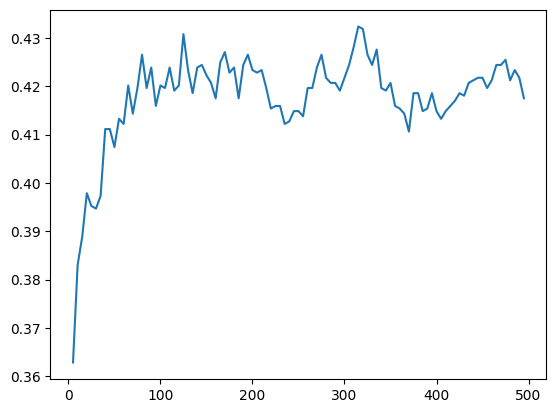

In [11]:
plt.plot(KS, correct_cat.mean(axis = 1))

In [18]:
KS[np.argmax(correct_cat.mean(axis = 1))], KS[np.argmax(correct_num.mean(axis = 1))]

(315, 250)

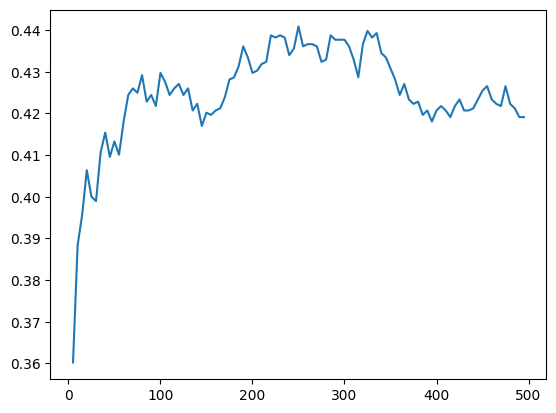

In [12]:
plt.plot(KS, correct_num.mean(axis = 1))